# CT Reconstruction Demo — Radon Transform and Filtered Backprojection

This notebook implements a basic CT reconstruction pipeline in Python.  
It starts with a 2D phantom image, generates projection data using the Radon transform, and visualizes the result as a sinogram. 

The reconstruction is then performed first using simple backprojection and later improved using filtered backprojection.
The flow is:

**phantom image → projections at multiple angles → sinogram → backprojection → filtered backprojection**

## Code Summary



The main processing steps are:

1. Create or load a simple phantom image.
2. Generate CT projections from multiple angles.
3. Build the sinogram from the projection data.
4. Apply unfiltered backprojection to reconstruct the image.
5. Apply FFT-based ramp filtering to improve reconstruction sharpness.
6. Compare the original image, sinogram, unfiltered reconstruction, and filtered reconstruction.


## 1. Import libraries

Only NumPy and Matplotlib are used so the processing steps stay transparent.

In [34]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Create a simple CT phantom

The phantom is a small artificial image made from circles.  
It acts like a simplified object that we want to reconstruct from projection data.

In [35]:
def add_circle(image, center_x, center_y, radius, value):
    """Add one filled circle to the image."""
    height, width = image.shape

    for row in range(height):
        for col in range(width):
            distance = np.sqrt((col - center_x) ** 2 + (row - center_y) ** 2)

            if distance <= radius:
                image[row, col] = value

    return image


def create_simple_phantom(size=96):
    """Create a simple CT phantom using a few circles."""
    image = np.zeros((size, size), dtype=float)
    center = size // 2

    image = add_circle(image, center, center, size * 0.32, 1.0)
    image = add_circle(image, center - size * 0.12, center - size * 0.08, size * 0.10, 0.35)
    image = add_circle(image, center + size * 0.13, center + size * 0.10, size * 0.08, 0.70)
    image = add_circle(image, center, center + size * 0.18, size * 0.06, 0.15)

    return image


def plot_image(image, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.colorbar()
    plt.show()

## 1. Object / Phantom Image

The original 2D object is represented as an image function:

$
f(x,y)
$

where \(f(x,y)\) describes the image intensity at position \((x,y)\).
In CT reconstruction, the goal is to recover this unknown image from its projections.

### Original phantom

This is the object before projection. In a real CT system, this would correspond to the object/body being scanned.

Image size: (96, 96)


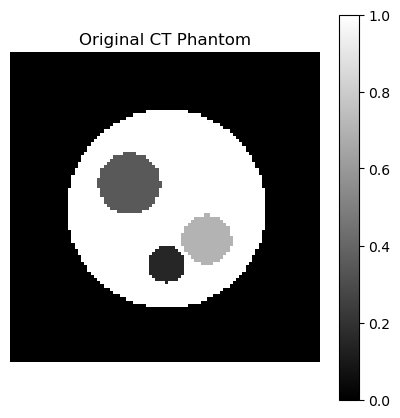

In [36]:
size = 96
phantom = create_simple_phantom(size=size)

print("Image size:", phantom.shape)
plot_image(phantom, "Original CT Phantom")

In [37]:
phantom
phantom.shape

(96, 96)

In [38]:
print(np.unique(phantom))

[0.   0.15 0.35 0.7  1.  ]


## 2. Projection at One Angle

For one projection angle $(\theta)$, the object is projected onto a detector axis $(s)$.
$$
s = x\cos(\theta) + y\sin(\theta)
$$

Each detector value represents the sum of image intensities along a line through the object.

## 3. Image rotation with bilinear interpolation

To create projections from different viewing angles, the image is rotated.  
Bilinear interpolation is used because rotated pixel locations usually fall between grid points.

### Important maths in image rotation

This code uses three main maths concepts:

1. **Coordinate shift**  
   Pixel coordinates are shifted so the image center becomes the origin.

   ```python
   x = col - center_x
   y = row - center_y

2. Rotation matrix

A 2D rotation is described by:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

So:

$$
x' = x\cos\theta - y\sin\theta
$$

$$
y' = x\sin\theta + y\cos\theta
$$

In the code, inverse rotation is used:

$$
x_s = x\cos\theta + y\sin\theta
$$

$$
y_s = -x\sin\theta + y\cos\theta
$$

This finds the source pixel location for each output pixel.

---

3. Bilinear interpolation

After rotation, the source point is usually not exactly on a pixel.  
For example, it may be at:

$$
(x, y) = (3.2, 5.7)
$$

So we use the four nearest pixels around it:

$$
A = I(y_0, x_0)
$$

$$
B = I(y_0, x_1)
$$

$$
C = I(y_1, x_0)
$$

$$
D = I(y_1, x_1)
$$

The fractional distances are:

$$
d_x = x - x_0
$$

$$
d_y = y - y_0
$$

The interpolated pixel value is:

$$
I(x,y) =
A(1-d_x)(1-d_y)
+ Bd_x(1-d_y)
+ C(1-d_x)d_y
+ Dd_xd_y
$$

In simple words, bilinear interpolation mixes the four nearest pixels.  
The closer a pixel is to the point, the more weight it gets.

In [7]:
def bilinear_sample(image, x, y):
    """Sample image at floating point coordinates using bilinear interpolation."""
    height, width = image.shape

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    x1 = x0 + 1
    y1 = y0 + 1

    if x0 < 0 or x1 >= width or y0 < 0 or y1 >= height:
        return 0.0

    dx = x - x0
    dy = y - y0

    value = (
        image[y0, x0] * (1 - dx) * (1 - dy)
        + image[y0, x1] * dx * (1 - dy)
        + image[y1, x0] * (1 - dx) * dy
        + image[y1, x1] * dx * dy
    )

    return value


def rotate_image(image, angle_degrees):
    """Rotate an image around its center using inverse mapping."""
    angle = np.deg2rad(angle_degrees)

    height, width = image.shape
    center_x = (width - 1) / 2
    center_y = (height - 1) / 2

    rotated = np.zeros_like(image, dtype=float)

    cos_a = np.cos(angle)
    sin_a = np.sin(angle)

    for row in range(height):
        for col in range(width):
            x = col - center_x
            y = row - center_y

            # inverse rotation: find where this output pixel came from
            source_x = cos_a * x + sin_a * y
            source_y = -sin_a * x + cos_a * y

            source_col = source_x + center_x
            source_row = source_y + center_y

            rotated[row, col] = bilinear_sample(image, source_col, source_row)

    return rotated

### Example rotated view

This is one intermediate view used during projection generation.

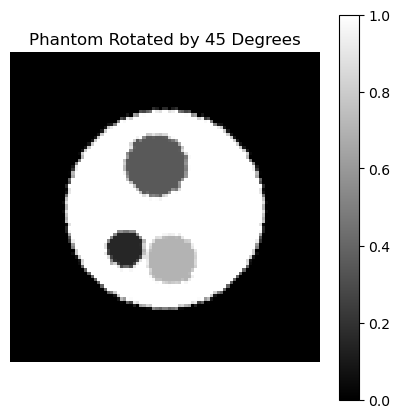

In [39]:
rotated_example = rotate_image(phantom, 45)
plot_image(rotated_example, "Phantom Rotated by 45 Degrees")

## 4. Radon transform and sinogram

For each angle, the image is rotated and summed along one axis.  
Each summed projection becomes one column in the sinogram.

## 3. Radon Transform

The CT projection data is described by the Radon transform:

$$
p_{\theta}(s) =
\int_{-\infty}^{\infty}
f(s\cos\theta - t\sin\theta,\;
s\sin\theta + t\cos\theta)\, dt
$$

Here, $($p_{\theta}(s))$ is the projection value at detector position \(s\) for angle $(\theta$).

In [40]:
def radon_transform(image, angles):
    """Compute a simple Radon transform by rotation and column summation."""
    projections = []

    for angle in angles:
        rotated = rotate_image(image, angle)
        projection = np.sum(rotated, axis=0)
        projections.append(projection)

    sinogram = np.array(projections).T

    return sinogram


def plot_sinogram(sinogram, angles, title="Sinogram"):
    plt.figure(figsize=(7, 5))
    plt.imshow(
        sinogram,
        cmap="gray",
        aspect="auto",
        extent=[angles[0], angles[-1], 0, sinogram.shape[0]]
    )
    plt.title(title)
    plt.xlabel("Projection angle in degrees")
    plt.ylabel("Detector position")
    plt.colorbar(label="Projection value")
    plt.show()

### Sinogram output

The sinogram stores how the object looks when projected from many angles.

## 4. Sinogram Formation

A sinogram stores all projections for different angles:

$
S(s,\theta) = p_{\theta}(s)
$

The horizontal axis usually represents the projection angle $\theta$, and the vertical axis represents the detector position $s$.

In unfiltered backprojection, each projection is smeared back across the image domain:

$$
\hat{f}_{BP}(x,y)
=
\int_{0}^{\pi}
p_{\theta}(x\cos\theta + y\sin\theta)
\, d\theta
$$

## 6. Fourier Transform of Projection

Before filtering, each projection is transformed into the frequency domain:

$$
P_{\theta}(\omega)
=
\mathcal{F}\{p_{\theta}(s)\}
$$

where $\omega$ is the spatial frequency and $\mathcal{F}$ denotes the Fourier transform.

Number of projection angles: 120


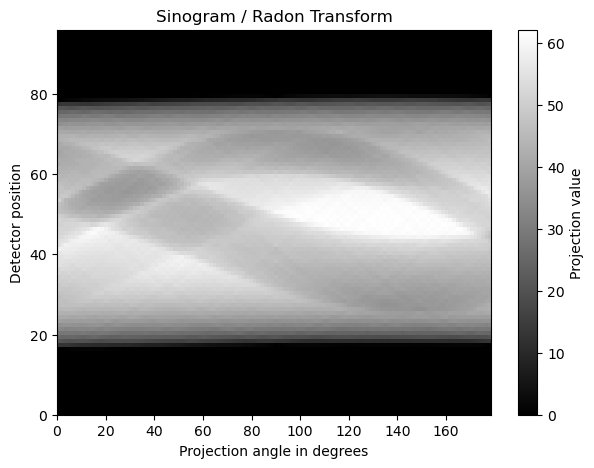

In [41]:
number_of_angles = 120
angles = np.linspace(0, 180, number_of_angles, endpoint=False)

sinogram = radon_transform(phantom, angles)

print("Number of projection angles:", len(angles))
plot_sinogram(sinogram, angles, title="Sinogram / Radon Transform")

In [42]:
angles

array([  0. ,   1.5,   3. ,   4.5,   6. ,   7.5,   9. ,  10.5,  12. ,
        13.5,  15. ,  16.5,  18. ,  19.5,  21. ,  22.5,  24. ,  25.5,
        27. ,  28.5,  30. ,  31.5,  33. ,  34.5,  36. ,  37.5,  39. ,
        40.5,  42. ,  43.5,  45. ,  46.5,  48. ,  49.5,  51. ,  52.5,
        54. ,  55.5,  57. ,  58.5,  60. ,  61.5,  63. ,  64.5,  66. ,
        67.5,  69. ,  70.5,  72. ,  73.5,  75. ,  76.5,  78. ,  79.5,
        81. ,  82.5,  84. ,  85.5,  87. ,  88.5,  90. ,  91.5,  93. ,
        94.5,  96. ,  97.5,  99. , 100.5, 102. , 103.5, 105. , 106.5,
       108. , 109.5, 111. , 112.5, 114. , 115.5, 117. , 118.5, 120. ,
       121.5, 123. , 124.5, 126. , 127.5, 129. , 130.5, 132. , 133.5,
       135. , 136.5, 138. , 139.5, 141. , 142.5, 144. , 145.5, 147. ,
       148.5, 150. , 151.5, 153. , 154.5, 156. , 157.5, 159. , 160.5,
       162. , 163.5, 165. , 166.5, 168. , 169.5, 171. , 172.5, 174. ,
       175.5, 177. , 178.5])

## 5. Ramp filtering in the frequency domain

Simple backprojection spreads each projection back into the image, but it creates blur.  
A ramp filter boosts useful high-frequency content before backprojection, which makes the final image sharper.

Filtered backprojection uses a ramp filter to strengthen high-frequency details:

$
H(\omega) = |\omega|
$

The filtered projection in the frequency domain is:

$$
{P}_{\theta}(\omega)
=
P_{\theta}(\omega)\,|\omega|
$$

This helps reduce the blurring caused by simple backprojection.

In [43]:
from torch import inverse


def ramp_filter_projection(projection):
    """Apply a simple Ram-Lak / ramp filter to one projection."""
    n = len(projection)

    frequency = np.fft.fftfreq(n)
    ramp = np.abs(frequency)
    projection_fft = np.fft.fft(projection)
    filtered_fft = projection_fft * ramp  

    filtered_projection = np.real(np.fft.ifft(filtered_fft)) 
    return filtered_projection


def filter_sinogram(sinogram):
    """Apply the ramp filter to every projection in the sinogram."""
    filtered = np.zeros_like(sinogram, dtype=float)
    for angle_index in range(sinogram.shape[1]):
        projection = sinogram[:, angle_index]
        filtered[:, angle_index] = ramp_filter_projection(projection)
    return filtered

### Filtered sinogram

The filtered sinogram is less smooth because high-frequency details are emphasized before reconstruction.

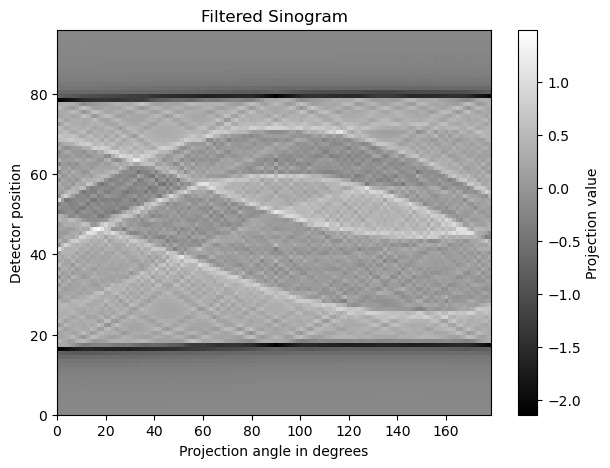

In [44]:
filtered_sinogram = filter_sinogram(sinogram)
plot_sinogram(filtered_sinogram, angles, title="Filtered Sinogram")

## 6. Backprojection

Backprojection reconstructs the image by spreading each projection value back over the image grid.

### Equations for simple CT backprojection

First, the pixel coordinates are shifted so that the image center becomes the origin:

$$
x = col - center_x
$$

$$
y = row - center_y
$$

For each projection angle $\theta$, the pixel position $(x,y)$ is projected onto the detector axis:

$$
s = x\cos\theta + y\sin\theta
$$

Here, $s$ is the detector position corresponding to the pixel.

The detector coordinate is converted into an array index by adding the detector center:

$$
i = s + detector\_center
$$

The sinogram value at this detector index is sampled:

$$
p_\theta(i)
$$

For one pixel, all projection values from all angles are added:

$$
f(x,y) = \sum_{\theta} p_\theta(i)
$$

Since

$$
i = x\cos\theta + y\sin\theta + detector\_center
$$

we can write:

$$
f(x,y) =
\sum_{\theta}
p_\theta(x\cos\theta + y\sin\theta + detector\_center)
$$

Finally, the reconstruction is scaled by:

$$
f(x,y) =
f(x,y)\cdot \frac{\pi}{2N}
$$

where $N$ is the number of projection angles.

So the complete backprojection equation is:

$$
f(x,y) =
\frac{\pi}{2N}
\sum_{\theta}
p_\theta(x\cos\theta + y\sin\theta + detector\_center)
$$

This is simple or unfiltered backprojection, so the reconstructed image is usually blurry.
```


In [50]:
from nbformat import convert
from networkx import center


def sample_projection(projection, index):
    """Linearly interpolate inside one projection."""
    left = int(np.floor(index))
    right = left + 1

    if left < 0 or right >= len(projection):
        return 0.0

    weight = index - left
    value = projection[left] * (1 - weight) + projection[right] * weight

    return float(value)


def backproject(sinogram, angles, output_size):
    """Backproject a sinogram into an image."""
    reconstruction = np.zeros((output_size, output_size), dtype=float)

    detector_count = sinogram.shape[0]
    detector_center = (detector_count - 1) / 2
    image_center = (output_size - 1) / 2

    for row in range(output_size):
        for col in range(output_size):
            x = col - image_center  
            y = row - image_center

            value = 0.0

            for angle_index, angle_degrees in enumerate(angles):  
                angle = np.deg2rad(angle_degrees)   

                detector_position = x * np.cos(angle) + y * np.sin(angle)  
                detector_index = detector_position + detector_center  

                value += sample_projection(sinogram[:, angle_index], detector_index) 

            reconstruction[row, col] = value 

    reconstruction = reconstruction * np.pi / (2 * len(angles)) 

    return reconstruction


def normalize_image(image):
    """Normalize an image to the range 0 to 1 for display."""
    image = image - np.min(image) 

    max_value = np.max(image) 
    if max_value > 0:
        image = image / max_value

    return image


def reconstruct_unfiltered(sinogram, angles, output_size):
    """Reconstruct using simple backprojection."""
    reconstruction = backproject(sinogram, angles, output_size) 
    return normalize_image(reconstruction)

def reconstruct_filtered(sinogram, angles, output_size):
    """Reconstruct using filtered backprojection."""
    filtered_sinogram = filter_sinogram(sinogram)
    reconstruction = backproject(filtered_sinogram, angles, output_size) 
    
    return normalize_image(reconstruction)

In [51]:
print("sinogram shape:", sinogram.shape)
print("number of angles:", len(angles))

sinogram shape: (96, 120)
number of angles: 120


## 7. Reconstruct the image

Now both reconstruction methods are applied:

- **Unfiltered backprojection:** easier to understand, but blurry.
- **Filtered backprojection:** sharper and closer to the original phantom.

In [52]:
unfiltered_reconstruction = reconstruct_unfiltered(sinogram, angles, output_size=size)
filtered_reconstruction = reconstruct_filtered(sinogram, angles, output_size=size)

In [53]:
print(type(unfiltered_reconstruction))
print(unfiltered_reconstruction.dtype)
print(unfiltered_reconstruction.shape)
print(type(unfiltered_reconstruction[0, 0]))
print(unfiltered_reconstruction[0, 0])

<class 'numpy.ndarray'>
float64
(96, 96)
<class 'numpy.float64'>
0.004498794043450827


### Unfiltered backprojection

The object shape is visible, but the image is blurred because projection values are smeared across the image.

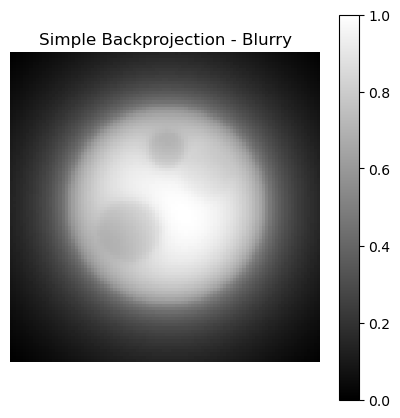

In [54]:
plot_image(unfiltered_reconstruction, "Simple Backprojection - Blurry")

### Filtered backprojection

Filtering before backprojection improves edge sharpness and reduces the typical backprojection blur.

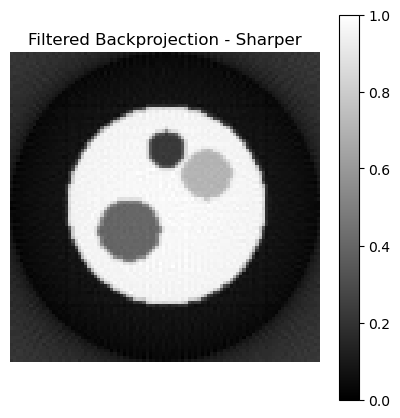

In [55]:
plot_image(filtered_reconstruction, "Filtered Backprojection - Sharper")

## 8. Final comparison

This side-by-side plot makes the improvement from filtering easier to see.

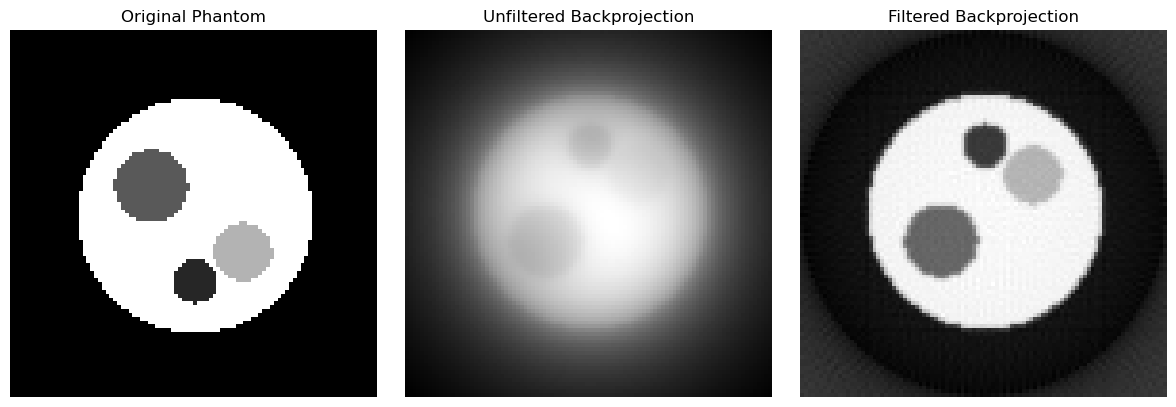

In [56]:
def plot_comparison(original, unfiltered, filtered):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original Phantom")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(unfiltered, cmap="gray")
    plt.title("Unfiltered Backprojection")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(filtered, cmap="gray")
    plt.title("Filtered Backprojection")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


plot_comparison(phantom, unfiltered_reconstruction, filtered_reconstruction)

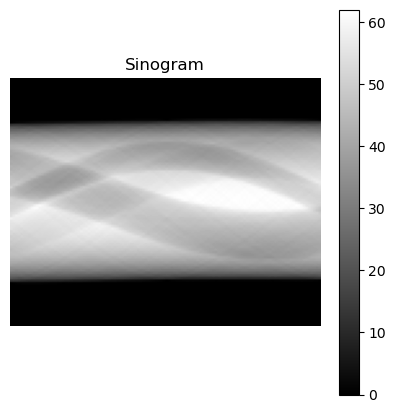

In [57]:
plot_image(sinogram, "Sinogram")

In [58]:
mse_unfiltered = np.mean((phantom - unfiltered_reconstruction) ** 2)
mse_filtered = np.mean((phantom - filtered_reconstruction) ** 2)

print("MSE Unfiltered:", mse_unfiltered)
print("MSE Filtered:", mse_filtered)

MSE Unfiltered: 0.07554432201860999
MSE Filtered: 0.052160973417281736


### Shepp-Logan Phantom

The Shepp-Logan phantom is a standard synthetic test image used in CT reconstruction.  
It is made from multiple ellipses with different intensity values.

Compared to the simple circular phantom, it is more realistic and better for testing reconstruction quality because it contains several structures, edges, and contrast levels.

In [60]:
def add_ellipse(image, x0, y0, a, b, angle_degrees, value):
    """
    Add a rotated ellipse to an image.

    x0, y0: center of ellipse, in normalized coordinates
    a, b: semi-major and semi-minor axes
    angle_degrees: ellipse rotation
    value: intensity added inside ellipse
    """
    size = image.shape[0]

    y, x = np.linspace(-1, 1, size), np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)

    angle = np.deg2rad(angle_degrees)

    Xc = X - x0
    Yc = Y - y0

    Xr = Xc * np.cos(angle) + Yc * np.sin(angle)
    Yr = -Xc * np.sin(angle) + Yc * np.cos(angle)

    mask = (Xr / a) ** 2 + (Yr / b) ** 2 <= 1

    image[mask] += value

    return image

In [62]:
def create_shepp_logan_phantom(size=96):
    """
    Create a simple Shepp-Logan-like CT phantom.
    """
    image = np.zeros((size, size), dtype=float)

    ellipses = [
        # x0,    y0,     a,      b,      angle,  value
        (0.0,   0.0,    0.69,   0.92,   0,      1.0),
        (0.0,  -0.018,  0.6624, 0.874,  0,     -0.8),
        (0.22,  0.0,    0.11,   0.31,  -18,    -0.2),
        (-0.22, 0.0,    0.16,   0.41,   18,    -0.2),
        (0.0,   0.35,   0.21,   0.25,   0,      0.1),
        (0.0,   0.1,    0.046,  0.046,  0,      0.1),
        (0.0,  -0.1,    0.046,  0.046,  0,      0.1),
        (-0.08,-0.605,  0.046,  0.023,  0,      0.1),
        (0.0,  -0.606,  0.023,  0.023,  0,      0.1),
        (0.06, -0.605,  0.023,  0.046,  0,      0.1),
    ]

    for ellipse in ellipses:
        image = add_ellipse(image, *ellipse)

    image = image - np.min(image)
    image = image / np.max(image)

    return image

In [63]:
def create_shepp_logan_phantom(size=96):
    """
    Create a simple Shepp-Logan-like CT phantom.
    """
    image = np.zeros((size, size), dtype=float)

    ellipses = [
        # x0,    y0,     a,      b,      angle,  value
        (0.0,   0.0,    0.69,   0.92,   0,      1.0),
        (0.0,  -0.018,  0.6624, 0.874,  0,     -0.8),
        (0.22,  0.0,    0.11,   0.31,  -18,    -0.2),
        (-0.22, 0.0,    0.16,   0.41,   18,    -0.2),
        (0.0,   0.35,   0.21,   0.25,   0,      0.1),
        (0.0,   0.1,    0.046,  0.046,  0,      0.1),
        (0.0,  -0.1,    0.046,  0.046,  0,      0.1),
        (-0.08,-0.605,  0.046,  0.023,  0,      0.1),
        (0.0,  -0.606,  0.023,  0.023,  0,      0.1),
        (0.06, -0.605,  0.023,  0.046,  0,      0.1),
    ]

    for ellipse in ellipses:
        image = add_ellipse(image, *ellipse)

    image = image - np.min(image)
    image = image / np.max(image)

    return image

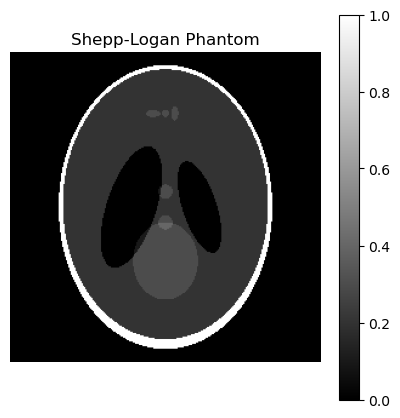

In [67]:
size = 256

phantom = create_shepp_logan_phantom(size)

plot_image(phantom, "Shepp-Logan Phantom")

In [68]:
angles = np.linspace(0, 180, 180, endpoint=False)

sinogram = radon_transform(phantom, angles)

unfiltered_reconstruction = reconstruct_unfiltered(sinogram, angles, output_size=size)
filtered_reconstruction = reconstruct_filtered(sinogram, angles, output_size=size)

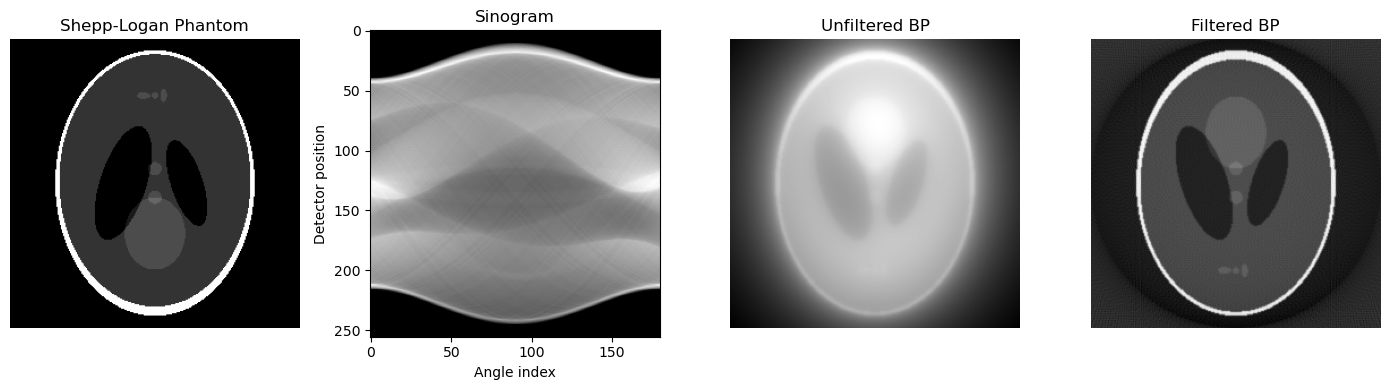

In [69]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(phantom, cmap="gray")
plt.title("Shepp-Logan Phantom")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(sinogram, cmap="gray", aspect="auto")
plt.title("Sinogram")
plt.xlabel("Angle index")
plt.ylabel("Detector position")

plt.subplot(1, 4, 3)
plt.imshow(unfiltered_reconstruction, cmap="gray")
plt.title("Unfiltered BP")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(filtered_reconstruction, cmap="gray")
plt.title("Filtered BP")
plt.axis("off")

plt.tight_layout()
plt.show()

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

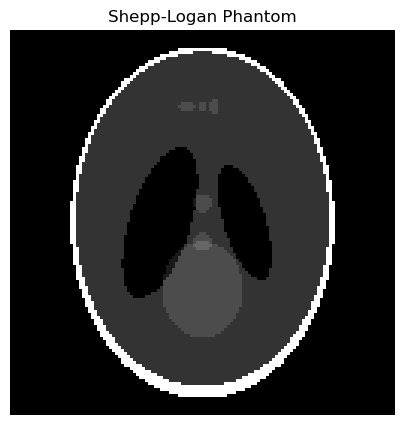

In [71]:
size = 128
phantom = create_shepp_logan_phantom(size)

angles = np.linspace(0, 180, 90, endpoint=False)

plt.figure(figsize=(5, 5))
plt.imshow(phantom, cmap="gray")
plt.title("Shepp-Logan Phantom")
plt.axis("off")
plt.show()